In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("garments_worker_productivity.csv")

In [3]:
# date -> verinin ait olduğu tarih
# quarter -> yılın hangi çeyreği 
# day -> haftanın günü
# department -> çalışılan bölüm
# team -> fabrikadaki ekip numarası
# no_of_workers -> o ekipte çalışan işçi sayısı
# targeted_productivity -> takım için belirtilen hedef verimlilik 
# actual_productivity -> gerçekleşen verimlilik
# smv -> bir ürünün üretilmesi için gereken standart dakika.işin zorluk derecesini gösterir
# wip -> o anda üretim hattında tamamlanmamış ürün sayısı
# over_time -> yapılan fazla mesai süresi
# Incentive -> işçilere verilen teşvik primi
# idle_time -> makine veya işçi boşta bekleme süresi
# idle_men -> o anda boşta kalan işçi sayısı
# no_of_style_change -> üretim sırasında model değişim sayısı
# 

In [4]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [6]:
for col in df.columns:
    print(df[col].value_counts())

date
3/11/2015    24
1/31/2015    24
1/11/2015    23
3/10/2015    23
1/12/2015    23
1/24/2015    23
1/8/2015     22
1/10/2015    22
1/7/2015     22
1/13/2015    22
1/5/2015     22
3/9/2015     22
3/8/2015     22
3/3/2015     22
1/22/2015    22
2/25/2015    21
2/26/2015    21
2/28/2015    21
1/3/2015     21
1/4/2015     21
1/28/2015    21
1/27/2015    21
3/4/2015     21
1/25/2015    21
1/17/2015    21
1/14/2015    21
1/6/2015     21
2/18/2015    21
1/29/2015    20
2/17/2015    20
3/2/2015     20
3/1/2015     20
2/22/2015    20
2/19/2015    20
3/5/2015     19
3/7/2015     19
2/24/2015    19
2/23/2015    19
1/1/2015     19
2/3/2015     19
2/15/2015    19
1/15/2015    19
1/18/2015    19
1/19/2015    19
1/21/2015    19
1/26/2015    19
2/1/2015     19
2/2/2015     19
2/4/2015     19
2/7/2015     19
2/8/2015     19
2/10/2015    19
2/11/2015    19
2/12/2015    19
2/5/2015     18
2/9/2015     18
2/16/2015    18
2/14/2015    17
1/20/2015    15
Name: count, dtype: int64
quarter
Quarter1    360
Q

In [7]:
df.corr(numeric_only=True)

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
team,1.000000,0.030274,-0.110011,-0.033474,-0.096737,-0.007674,0.003796,0.026974,-0.011194,-0.075113,-0.148753
targeted_productivity,0.030274,1.000000,-0.069489,0.062054,-0.088557,0.032768,-0.056181,-0.053818,-0.209294,-0.084288,0.421594
smv,-0.110011,-0.069489,1.000000,-0.037837,0.674887,0.032629,0.056863,0.105901,0.315388,0.912176,-0.122089
wip,-0.033474,0.062054,-0.037837,1.000000,0.022302,0.167210,-0.026299,-0.048718,-0.072357,0.030383,0.131147
over_time,-0.096737,-0.088557,0.674887,0.022302,1.000000,-0.004793,0.031038,-0.017913,0.059790,0.734164,-0.054206
incentive,-0.007674,0.032768,0.032629,0.167210,-0.004793,1.000000,-0.012024,-0.021140,-0.026607,0.049222,0.076538
idle_time,0.003796,-0.056181,0.056863,-0.026299,0.031038,-0.012024,1.000000,0.559146,-0.011598,0.058049,-0.080851
idle_men,0.026974,-0.053818,0.105901,-0.048718,-0.017913,-0.021140,0.559146,1.000000,0.133632,0.106946,-0.181734
no_of_style_change,-0.011194,-0.209294,0.315388,-0.072357,0.059790,-0.026607,-0.011598,0.133632,1.000000,0.327787,-0.207366
no_of_workers,-0.075113,-0.084288,0.912176,0.030383,0.734164,0.049222,0.058049,0.106946,0.327787,1.000000,-0.057991


In [8]:
df = df.drop("date",axis=1)

In [9]:
df = pd.get_dummies(df,columns=["quarter"],drop_first=True)

In [10]:
df["department"].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [11]:
df["department"] = df["department"].str.strip()

In [12]:
df["department"].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

In [13]:
df["department"] = df["department"].replace("sweing","sewing")

In [14]:
df = pd.get_dummies(df,columns=["department"],drop_first=True)

In [15]:
df = pd.get_dummies(df,columns=["day"],drop_first=False)

In [16]:
df.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,False,False,False,True,False,False,False,True,False,False
1,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,...,False,False,False,False,False,False,False,True,False,False
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,False,False,False,True,False,False,False,True,False,False
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,False,False,False,True,False,False,False,True,False,False
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,False,False,False,True,False,False,False,True,False,False


In [17]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [18]:
df.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,0,0,0,1,0,0,0,1,0,0
1,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,0,0,0,1,0,0,0,1,0,0


In [19]:
df.isna().sum()

team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
quarter_Quarter2           0
quarter_Quarter3           0
quarter_Quarter4           0
quarter_Quarter5           0
department_sewing          0
day_Monday                 0
day_Saturday               0
day_Sunday                 0
day_Thursday               0
day_Tuesday                0
day_Wednesday              0
dtype: int64

In [20]:
df[df.isna().any(axis=1)]

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
1,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
6,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
13,10,0.65,3.94,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
14,8,0.75,2.90,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
15,4,0.75,3.94,NaN,2160,0,0.0,0,0,18.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,0,0,1
1193,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,0,0,1
1194,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,0,0,1
1195,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,...,0,0,0,0,0,0,0,0,0,1


In [21]:
df["wip"].fillna(df["wip"].median(), inplace=True)

C:\Users\rarsl\AppData\Local\Temp\ipykernel_23320\350471149.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["wip"].fillna(df["wip"].median(), inplace=True)


In [22]:
df.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,0,0,0,1,0,0,0,1,0,0
1,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,0,0,0,1,0,0,0,1,0,0


In [23]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,...,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1126.437761,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,...,0.175439,0.207185,0.036759,0.577277,0.166249,0.156224,0.169591,0.166249,0.167920,0.173768
std,3.463963,0.097891,10.943219,1397.653191,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,...,0.380501,0.405458,0.188247,0.494199,0.372460,0.363219,0.375430,0.372460,0.373951,0.379068
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.700000,3.940000,970.000000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.000000,0.800000,24.260000,1083.000000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
df.isna().sum()

team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
quarter_Quarter2         0
quarter_Quarter3         0
quarter_Quarter4         0
quarter_Quarter5         0
department_sewing        0
day_Monday               0
day_Saturday             0
day_Sunday               0
day_Thursday             0
day_Tuesday              0
day_Wednesday            0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [26]:
df.corr()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
team,1.000000,0.030274,-0.110011,-0.023647,-0.096737,-0.007674,0.003796,0.026974,-0.011194,-0.075113,...,0.028769,0.007220,0.000277,0.031753,0.019472,-0.006533,0.000861,-0.011635,0.001416,-0.003690
targeted_productivity,0.030274,1.000000,-0.069489,0.045428,-0.088557,0.032768,-0.056181,-0.053818,-0.209294,-0.084288,...,-0.039795,-0.078973,-0.022860,-0.067508,-0.001074,0.017842,0.036051,-0.040747,-0.009276,-0.002558
smv,-0.110011,-0.069489,1.000000,0.028526,0.674887,0.032629,0.056863,0.105901,0.315388,0.912176,...,0.036639,-0.006510,-0.018811,0.874230,0.000305,-0.016807,0.004015,0.002882,0.009399,-0.000277
wip,-0.023647,0.045428,0.028526,1.000000,0.050755,0.024301,-0.023596,-0.043241,-0.052790,0.060086,...,-0.030749,-0.021216,-0.001704,0.053557,0.180224,-0.033093,-0.032498,-0.040262,-0.033121,-0.040952
over_time,-0.096737,-0.088557,0.674887,0.050755,1.000000,-0.004793,0.031038,-0.017913,0.059790,0.734164,...,0.045272,0.043339,-0.049138,0.677519,-0.027983,0.016666,0.002245,0.084735,-0.017185,-0.057001
incentive,-0.007674,0.032768,0.032629,0.024301,-0.004793,1.000000,-0.012024,-0.021140,-0.026607,0.049222,...,-0.043119,-0.042757,-0.006135,0.045782,0.173065,-0.031046,-0.039635,-0.033605,-0.032179,-0.036281
idle_time,0.003796,-0.056181,0.056863,-0.023596,0.031038,-0.012024,1.000000,0.559146,-0.011598,0.058049,...,-0.019940,-0.028082,-0.011227,0.049181,-0.025311,0.078508,-0.022906,-0.023456,-0.022388,0.017463
idle_men,0.026974,-0.053818,0.105901,-0.043241,-0.017913,-0.021140,0.559146,1.000000,0.133632,0.106946,...,0.072232,-0.029381,-0.022075,0.096701,-0.043594,0.009119,0.010247,0.001042,0.014213,0.008903
no_of_style_change,-0.011194,-0.209294,0.315388,-0.052790,0.059790,-0.026607,-0.011598,0.133632,1.000000,0.327787,...,0.074066,0.191381,-0.068688,0.300889,-0.004852,-0.011408,-0.033972,0.021382,0.009273,0.019187
no_of_workers,-0.075113,-0.084288,0.912176,0.060086,0.734164,0.049222,0.058049,0.106946,0.327787,1.000000,...,0.038056,-0.004250,-0.025979,0.939360,0.005829,-0.021575,-0.006652,0.015184,0.007546,-0.000830


In [27]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                colname = corr.columns[i]
                columns_to_drop.add(colname)
    return columns_to_drop

In [28]:
correlation_for_dropping(df,threshold=0.8)

{'department_sewing', 'no_of_workers'}

In [29]:
df.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,0,0,0,1,0,0,0,1,0,0
1,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,0,0,0,1,0,0,0,1,0,0


In [30]:
df[["team","actual_productivity"]].corr()

,team,actual_productivity
team,1.000000,-0.148753
actual_productivity,-0.148753,1.000000


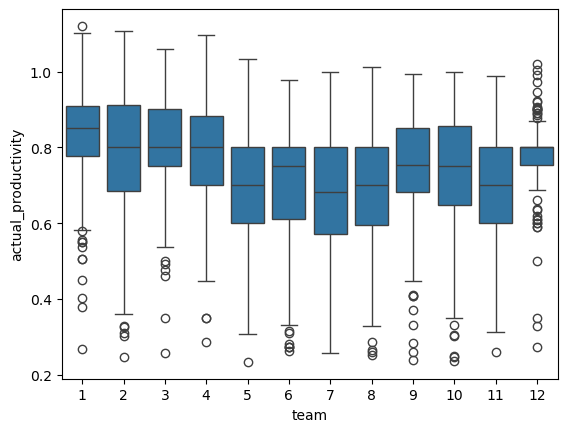

In [31]:
sns.boxplot(data=df,x="team",y="actual_productivity")
plt.show()

In [32]:
def fin_outliers_iqr(df,threshold=1.5):
    outlier_summary = {}

    columns = df.columns
   
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }

    return pd.DataFrame(outlier_summary)

In [33]:
fin_outliers_iqr(df,threshold=1.5)

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
outlier_count,0.0,79.000000,0.00,358.000000,1.000000,11.000000,18.000000,18.000000,147.000000,0.0,...,210.00000,248.000000,44.000000,0.0,199.000000,187.000000,203.000000,199.000000,201.00000,208.000000
outlier_percentage,0.0,6.599833,0.00,29.908104,0.083542,0.918964,1.503759,1.503759,12.280702,0.0,...,17.54386,20.718463,3.675856,0.0,16.624896,15.622389,16.959064,16.624896,16.79198,17.376775
lower_bound,-6.0,0.550000,-26.54,800.500000,-6840.000000,-75.000000,0.000000,0.000000,0.000000,-63.0,...,0.00000,0.000000,0.000000,-1.5,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
upper_bound,18.0,0.950000,54.74,1252.500000,15240.000000,125.000000,0.000000,0.000000,0.000000,129.0,...,0.00000,0.000000,0.000000,2.5,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


In [34]:
def remove_outliers_from_column(df,target_col,threshold=1.5):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return df[(df[target_col] >= lower_bound) & (df[target_col] <=upper_bound)]

In [35]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"targeted_productivity")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (1118, 22)


In [36]:
Q1 = df["targeted_productivity"].quantile(0.25)
Q3 = df["targeted_productivity"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["targeted_productivity"] = df["targeted_productivity"].clip(lower=lower_bound,upper=upper_bound)

In [37]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"wip")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (839, 22)


In [38]:
Q1 = df["wip"].quantile(0.25)
Q3 = df["wip"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["wip"] = df["wip"].clip(lower=lower_bound,upper=upper_bound)

In [39]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"no_of_style_change")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (1050, 22)


In [40]:
Q1 = df["no_of_style_change"].quantile(0.25)
Q3 = df["no_of_style_change"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["no_of_style_change"] = df["no_of_style_change"].clip(lower=lower_bound,upper=upper_bound)

In [41]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"quarter_Quarter3")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (987, 22)


In [42]:
Q1 = df["quarter_Quarter3"].quantile(0.25)
Q3 = df["quarter_Quarter3"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["quarter_Quarter3"] = df["quarter_Quarter3"].clip(lower=lower_bound,upper=upper_bound)

In [43]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"quarter_Quarter4")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (949, 22)


In [44]:
Q1 = df["quarter_Quarter4"].quantile(0.25)
Q3 = df["quarter_Quarter4"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["quarter_Quarter4"] = df["quarter_Quarter4"].clip(lower=lower_bound,upper=upper_bound)

In [45]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"quarter_Quarter5")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (1153, 22)


In [46]:
Q1 = df["quarter_Quarter5"].quantile(0.25)
Q3 = df["quarter_Quarter5"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["quarter_Quarter5"] = df["quarter_Quarter5"].clip(lower=lower_bound,upper=upper_bound)

In [47]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"day_Monday")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (998, 22)


In [48]:
Q1 = df["day_Monday"].quantile(0.25)
Q3 = df["day_Monday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Monday"] = df["day_Monday"].clip(lower=lower_bound,upper=upper_bound)

In [49]:
Q1 = df["day_Saturday"].quantile(0.25)
Q3 = df["day_Saturday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Saturday"] = df["day_Saturday"].clip(lower=lower_bound,upper=upper_bound)

In [50]:
Q1 = df["day_Sunday"].quantile(0.25)
Q3 = df["day_Sunday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Sunday"] = df["day_Sunday"].clip(lower=lower_bound,upper=upper_bound)

In [51]:
Q1 = df["day_Thursday"].quantile(0.25)
Q3 = df["day_Thursday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Thursday"] = df["day_Thursday"].clip(lower=lower_bound,upper=upper_bound)

In [52]:
Q1 = df["day_Tuesday"].quantile(0.25)
Q3 = df["day_Tuesday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Tuesday"] = df["day_Tuesday"].clip(lower=lower_bound,upper=upper_bound)

In [53]:
Q1 = df["day_Wednesday"].quantile(0.25)
Q3 = df["day_Wednesday"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["day_Wednesday"] = df["day_Wednesday"].clip(lower=lower_bound,upper=upper_bound)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [55]:
print("Original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df,"department_sewing")
print("Only target column cleaning shape: ",df_target_clean.shape)

Original data shape:  (1197, 22)
Only target column cleaning shape:  (1197, 22)


In [56]:
Q1 = df["incentive"].quantile(0.25)
Q3 = df["incentive"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["incentive"] = df["incentive"].clip(lower=lower_bound,upper=upper_bound)

In [57]:
Q1 = df["idle_time"].quantile(0.25)
Q3 = df["idle_time"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["idle_time"] = df["idle_time"].clip(lower=lower_bound,upper=upper_bound)

In [58]:
Q1 = df["idle_men"].quantile(0.25)
Q3 = df["idle_men"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["idle_men"] = df["idle_men"].clip(lower=lower_bound,upper=upper_bound)

In [59]:
Q1 = df["actual_productivity"].quantile(0.25)
Q3 = df["actual_productivity"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df["actual_productivity"] = df["actual_productivity"].clip(lower=lower_bound,upper=upper_bound)

In [60]:
import math
def plot_all_histograms(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i, col in enumerate (num_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],bins=30,kde=True)
        plt.title(col)
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

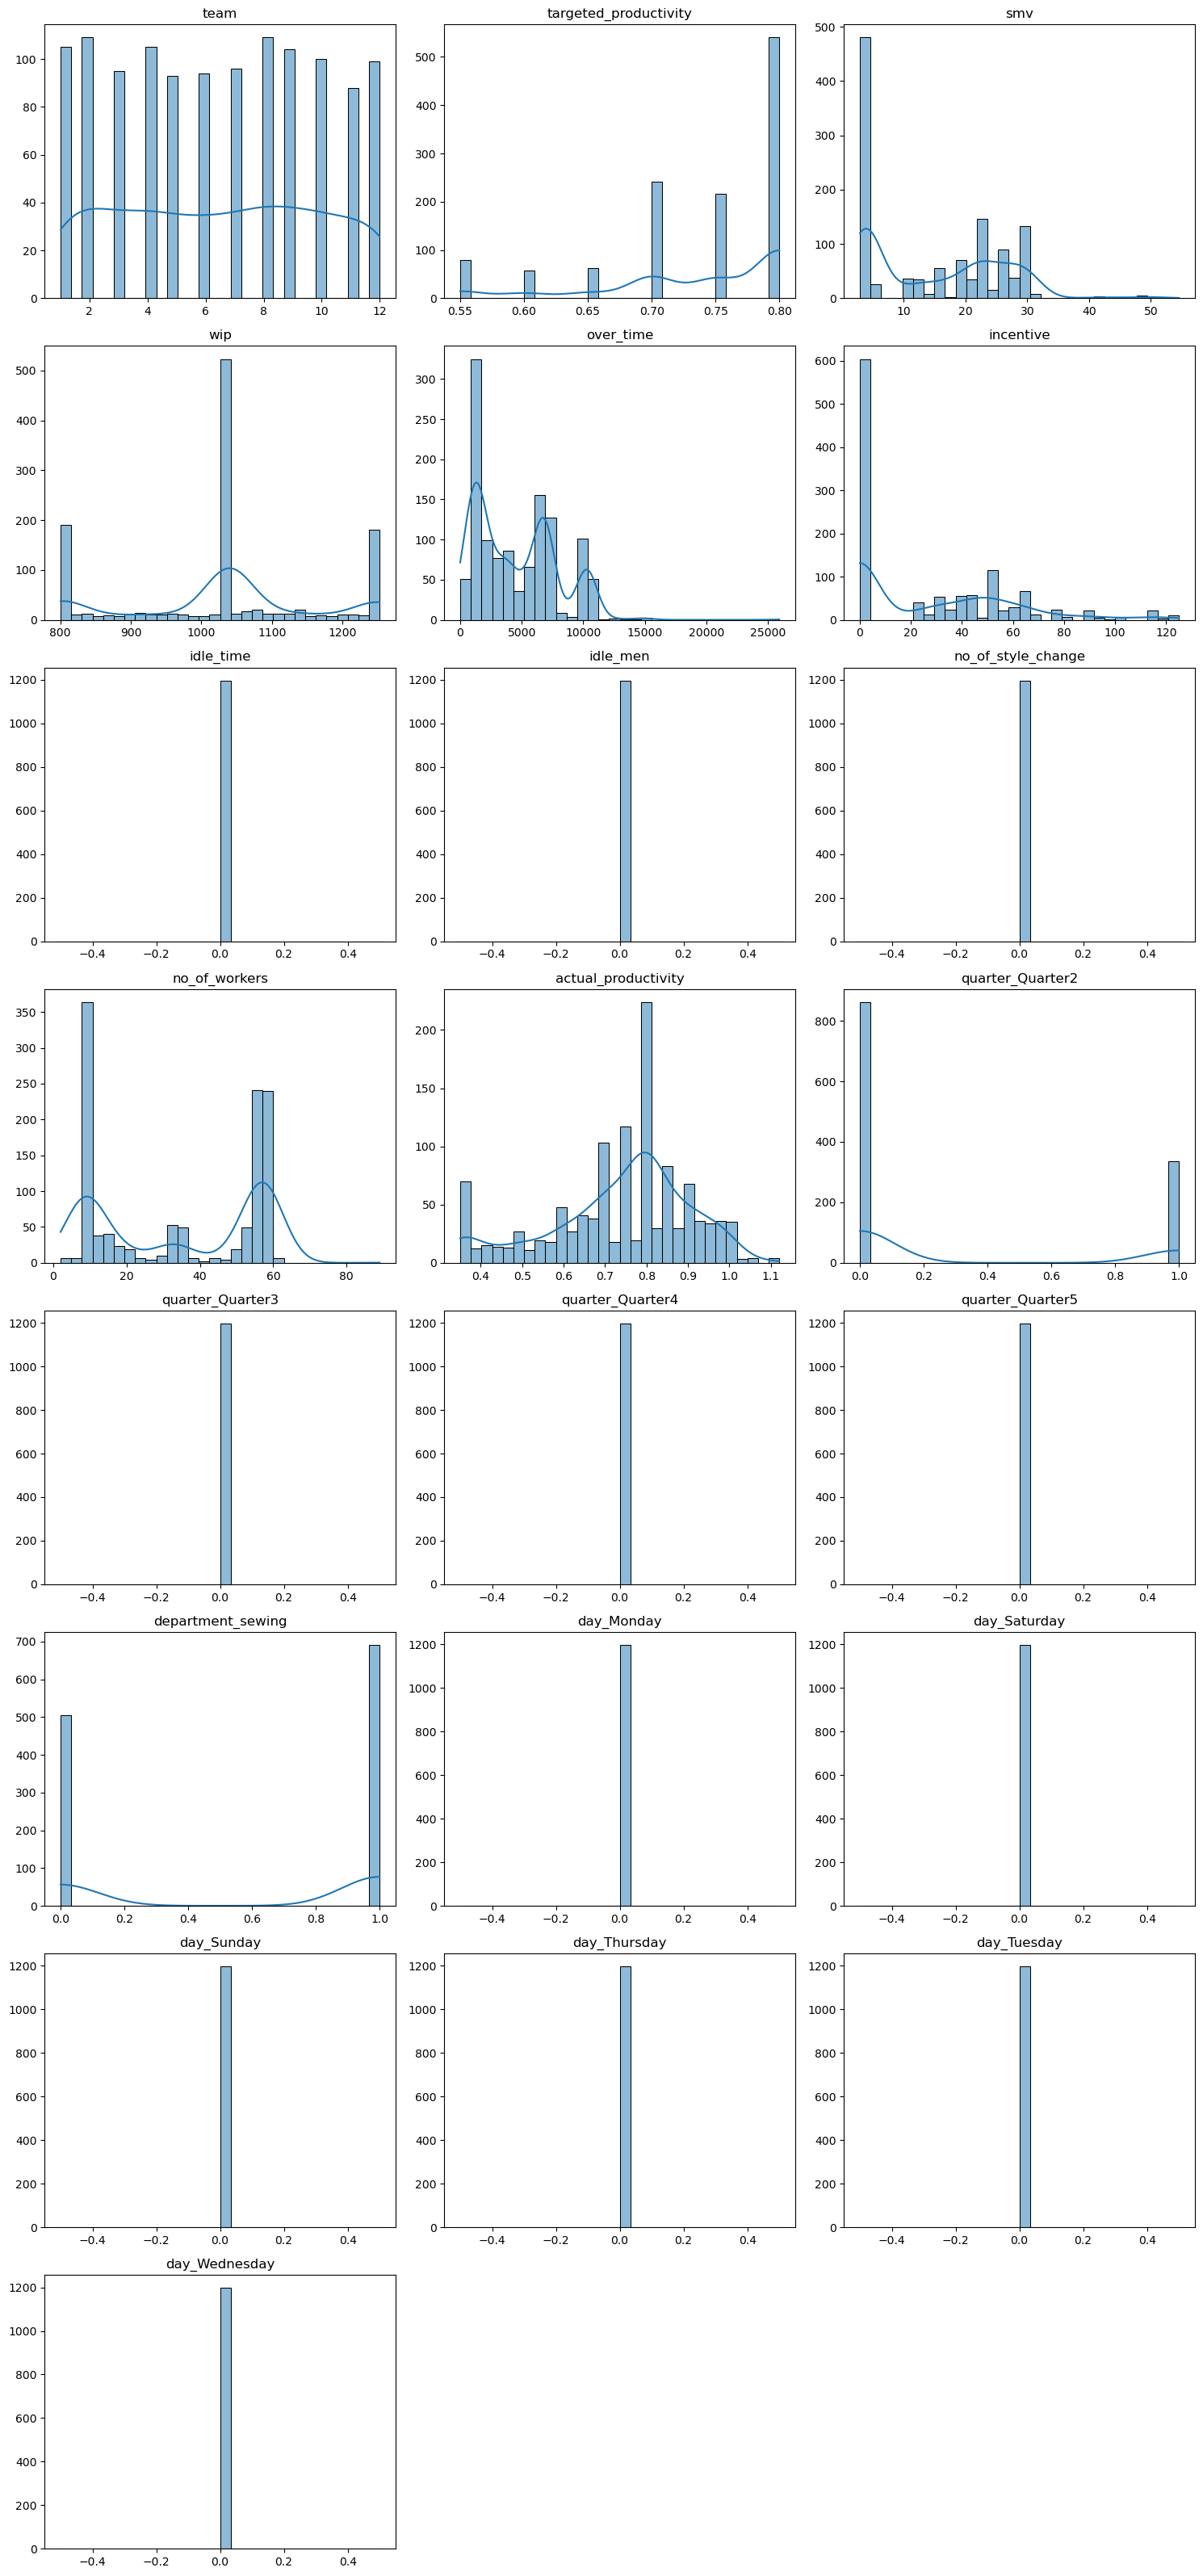

In [61]:
plot_all_histograms(df)

In [62]:
print(df["idle_time"].unique())
print(df["idle_men"].unique())

[0.]
[0]


In [63]:
# gerçek üretim iş yükü
df["workload"] = df["smv"] * df["no_of_workers"]

In [64]:
# fazla mesainin kişi başı etkisi
df["overtime_ratio"] = df["over_time"] / df["no_of_workers"]

In [65]:
# hedefe göre işi yükü
df["targeted_workload"] = df["targeted_productivity"] * df["smv"]

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [67]:
drop_columns = ["smv","targeted_productivity","over_time"]

In [68]:
df = df.drop(columns=drop_columns)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 1197 non-null   int64  
 1   wip                  1197 non-null   float64
 2   incentive            1197 non-null   int64  
 3   idle_time            1197 non-null   float64
 4   idle_men             1197 non-null   int64  
 5   no_of_style_change   1197 non-null   int64  
 6   no_of_workers        1197 non-null   float64
 7   actual_productivity  1197 non-null   float64
 8   quarter_Quarter2     1197 non-null   int64  
 9   quarter_Quarter3     1197 non-null   int64  
 10  quarter_Quarter4     1197 non-null   int64  
 11  quarter_Quarter5     1197 non-null   int64  
 12  department_sewing    1197 non-null   int64  
 13  day_Monday           1197 non-null   int64  
 14  day_Saturday         1197 non-null   int64  
 15  day_Sunday           1197 non-null   i

In [70]:
df.head()

,team,wip,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,quarter_Quarter2,quarter_Quarter3,...,department_sewing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,workload,overtime_ratio,targeted_workload
0,8,1108.0,98,0.0,0,0,59.0,0.940725,0,0,...,1,0,0,0,0,0,0,1543.440,120.000000,20.928
1,1,1039.0,0,0.0,0,0,8.0,0.886500,0,0,...,0,0,0,0,0,0,0,31.520,120.000000,2.955
2,11,968.0,50,0.0,0,0,30.5,0.800570,0,0,...,1,0,0,0,0,0,0,348.005,120.000000,9.128
3,12,968.0,50,0.0,0,0,30.5,0.800570,0,0,...,1,0,0,0,0,0,0,348.005,120.000000,9.128
4,6,1170.0,50,0.0,0,0,56.0,0.800382,0,0,...,1,0,0,0,0,0,0,1450.400,34.285714,20.720


In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X = df.drop("actual_productivity",axis=1)
y = df["actual_productivity"]

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [74]:
from sklearn.preprocessing import StandardScaler

In [75]:
scaler = StandardScaler()

In [76]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [78]:
scaler_model = {
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "KNeighbors Regressor" : KNeighborsRegressor(),
    "SVR" : SVR()
}

In [79]:
models = {
    "Decision Tree Regressor" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "Gradient Boosting Regressor" : GradientBoostingRegressor(),
    "AdaBoost Regressor" : AdaBoostRegressor(),
    "XGBM Regressor" : XGBRegressor(),
    "LGBM Regressor" : LGBMRegressor()
}

In [80]:
import warnings
warnings.filterwarnings("ignore")

In [81]:
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

In [82]:
def training_all_models(X_train, X_test, y_train, y_test, models):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(name)
        print("R2 Score: ",r2_score(y_test, y_pred))
        print("Mean Absolute Error: ",mean_absolute_error(y_test, y_pred))
        print("Mean Squared Error ",mean_squared_error(y_test, y_pred))
        print("------------------------------------------")


In [83]:
training_all_models(X_train_scaled,X_test_scaled,y_train,y_test,scaler_model)

Linear Regression
R2 Score:  0.41678083390993603
Mean Absolute Error:  0.08626088143015188
Mean Squared Error  0.014610994179460591
------------------------------------------
Ridge
R2 Score:  0.4167832124226115
Mean Absolute Error:  0.08641926177291864
Mean Squared Error  0.01461093459219584
------------------------------------------
Lasso
R2 Score:  -0.0061001192848928465
Mean Absolute Error:  0.12517910928096482
Mean Squared Error  0.025205143866201582
------------------------------------------
KNeighbors Regressor
R2 Score:  0.35309515085903387
Mean Absolute Error:  0.08932282155833333
Mean Squared Error  0.01620646839991515
------------------------------------------
SVR
R2 Score:  0.4024960787221138
Mean Absolute Error:  0.08896605436361144
Mean Squared Error  0.014968860462051276
------------------------------------------


In [84]:
training_all_models(X_train,X_test,y_train,y_test,models)

Decision Tree Regressor
R2 Score:  0.06138007323086103
Mean Absolute Error:  0.09820285971819445
Mean Squared Error  0.023514608373881522
------------------------------------------
Random Forest Regressor
R2 Score:  0.3751024561127413
Mean Absolute Error:  0.08121086430747912
Mean Squared Error  0.015655134308610825
------------------------------------------
Gradient Boosting Regressor
R2 Score:  0.4514398065191878
Mean Absolute Error:  0.08273599351218539
Mean Squared Error  0.013742706447329271
------------------------------------------
AdaBoost Regressor
R2 Score:  0.27775757737454987
Mean Absolute Error:  0.0995479182833186
Mean Squared Error  0.018093849528104097
------------------------------------------
XGBM Regressor
R2 Score:  0.3309318303980403
Mean Absolute Error:  0.08399820409280294
Mean Squared Error  0.0167617110343849
------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000056 seconds.
You can

In [85]:
params = {
        "n_estimators" : [100,150,200],
        "max_depth" : [3,4,5],
        "loss" :["squared_error", "absolute_error", "huber", "quantile"],
        "learning_rate" : [0.01,0.1,0.5,1]
}

In [86]:
from sklearn.model_selection import RandomizedSearchCV

In [87]:
random = RandomizedSearchCV(estimator=GradientBoostingRegressor(),param_distributions=params,cv=5,n_jobs=-1)

In [88]:
random.fit(X_train,y_train)

,estimator,GradientBoostingRegressor()
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'loss': ['squared_error', 'absolute_error', ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [89]:
y_pred = random.predict(X_test)

In [90]:
print("R2 Score: ",r2_score(y_test, y_pred))
print("Mean Absolute Error: ",mean_absolute_error(y_test, y_pred))
print("Mean Squared Error ",mean_squared_error(y_test, y_pred))

R2 Score:  0.4449567519673845
Mean Absolute Error:  0.07574166397594113
Mean Squared Error  0.01390512201565937


In [91]:
data = pd.read_csv("garments_worker_productivity.csv")

In [92]:
data.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [93]:
data = data.drop("date",axis=1)

In [94]:
data.head()

,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   int64  
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   wip                    691 non-null    float64
 7   over_time              1197 non-null   int64  
 8   incentive              1197 non-null   int64  
 9   idle_time              1197 non-null   float64
 10  idle_men               1197 non-null   int64  
 11  no_of_style_change     1197 non-null   int64  
 12  no_of_workers          1197 non-null   float64
 13  actual_productivity    1197 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 131.1+ 

In [96]:
data["wip"].unique()

array([1.1080e+03,        nan, 9.6800e+02, 1.1700e+03, 9.8400e+02,
       7.9500e+02, 7.3300e+02, 6.8100e+02, 8.7200e+02, 5.7800e+02,
       6.6800e+02, 8.6100e+02, 7.7200e+02, 9.1300e+02, 1.2610e+03,
       8.4400e+02, 1.0050e+03, 6.5900e+02, 1.1520e+03, 1.1380e+03,
       6.1000e+02, 9.4400e+02, 5.4400e+02, 1.0720e+03, 5.3900e+02,
       1.2780e+03, 1.2270e+03, 1.0390e+03, 8.7800e+02, 1.0330e+03,
       7.8200e+02, 1.2160e+03, 5.1300e+02, 7.3400e+02, 1.2020e+03,
       8.8400e+02, 1.2550e+03, 1.0470e+03, 6.7800e+02, 7.1200e+02,
       1.0370e+03, 7.5700e+02, 7.5900e+02, 1.0830e+03, 6.6600e+02,
       1.1870e+03, 1.3050e+03, 7.1600e+02, 9.2500e+02, 9.6300e+02,
       1.1010e+03, 1.0350e+03, 9.1000e+02, 1.2090e+03, 5.9000e+02,
       8.0800e+02, 1.1790e+03, 1.3240e+03, 1.1350e+03, 7.7600e+02,
       9.9000e+02, 9.8600e+02, 9.2400e+02, 1.1200e+03, 1.0660e+03,
       1.1440e+03, 4.1300e+02, 5.6800e+02, 1.1890e+03, 9.4200e+02,
       1.0500e+03, 1.0260e+03, 7.8300e+02, 8.5700e+02, 5.4800e

In [97]:
data["wip"].describe()

count      691.000000
mean      1190.465991
std       1837.455001
min          7.000000
25%        774.500000
50%       1039.000000
75%       1252.500000
max      23122.000000
Name: wip, dtype: float64

In [98]:
data["wip"].fillna(data["wip"].median(),inplace=True)

In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   int64  
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   wip                    1197 non-null   float64
 7   over_time              1197 non-null   int64  
 8   incentive              1197 non-null   int64  
 9   idle_time              1197 non-null   float64
 10  idle_men               1197 non-null   int64  
 11  no_of_style_change     1197 non-null   int64  
 12  no_of_workers          1197 non-null   float64
 13  actual_productivity    1197 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 131.1+ 

In [100]:
data["quarter"].unique()

array(['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5'],
      dtype=object)

In [101]:
data = pd.get_dummies(data,columns=["quarter"],drop_first=True)

In [102]:
data["department"].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [103]:
data["department"] = data["department"].str.strip()

In [104]:
data["department"].unique()

array(['sweing', 'finishing'], dtype=object)

In [105]:
data = pd.get_dummies(data,columns=["department"],drop_first=True)

In [106]:
data["day"].unique()

array(['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object)

In [107]:
data = pd.get_dummies(data,columns=["day"],drop_first=False)

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   bool   
 12  quarter_Quarter3       1197 non-null   bool   
 13  quarter_Quarter4       1197 non-null   bool   
 14  quarter_Quarter5       1197 non-null   bool   
 15  depa

In [109]:
data.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,False,False,False,True,False,False,False,True,False,False
1,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,...,False,False,False,False,False,False,False,True,False,False
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,False,False,False,True,False,False,False,True,False,False
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,False,False,False,True,False,False,False,True,False,False
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,False,False,False,True,False,False,False,True,False,False


In [110]:
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [112]:
data.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,...,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1126.437761,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,...,0.175439,0.207185,0.036759,0.577277,0.166249,0.156224,0.169591,0.166249,0.167920,0.173768
std,3.463963,0.097891,10.943219,1397.653191,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,...,0.380501,0.405458,0.188247,0.494199,0.372460,0.363219,0.375430,0.372460,0.373951,0.379068
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.700000,3.940000,970.000000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.000000,0.800000,24.260000,1083.000000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [113]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [115]:
def cap_outliers_iqr(df, target_col=None, factor=1.5, verbose=True):
    import numpy as np
    
    df = df.copy()
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if target_col and target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        
        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        
        if verbose and outlier_count > 0:
            print(f"{col}: {outlier_count} outlier bulundu")
        
        df[col] = df[col].clip(lower=lower, upper=upper)
    
    return df

In [116]:
print("Original data shape:", data.shape)

data_clean = cap_outliers_iqr(data, target_col="actual_productivity")

print("Cleaned data shape:", data_clean.shape)

Original data shape: (1197, 22)
targeted_productivity: 79 outlier bulundu
wip: 358 outlier bulundu
over_time: 1 outlier bulundu
incentive: 11 outlier bulundu
idle_time: 18 outlier bulundu
idle_men: 18 outlier bulundu
no_of_style_change: 147 outlier bulundu
quarter_Quarter3: 210 outlier bulundu
quarter_Quarter4: 248 outlier bulundu
quarter_Quarter5: 44 outlier bulundu
day_Monday: 199 outlier bulundu
day_Saturday: 187 outlier bulundu
day_Sunday: 203 outlier bulundu
day_Thursday: 199 outlier bulundu
day_Tuesday: 201 outlier bulundu
day_Wednesday: 208 outlier bulundu
Cleaned data shape: (1197, 22)


In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   team                   1197 non-null   int64  
 1   targeted_productivity  1197 non-null   float64
 2   smv                    1197 non-null   float64
 3   wip                    1197 non-null   float64
 4   over_time              1197 non-null   int64  
 5   incentive              1197 non-null   int64  
 6   idle_time              1197 non-null   float64
 7   idle_men               1197 non-null   int64  
 8   no_of_style_change     1197 non-null   int64  
 9   no_of_workers          1197 non-null   float64
 10  actual_productivity    1197 non-null   float64
 11  quarter_Quarter2       1197 non-null   int64  
 12  quarter_Quarter3       1197 non-null   int64  
 13  quarter_Quarter4       1197 non-null   int64  
 14  quarter_Quarter5       1197 non-null   int64  
 15  depa

In [118]:
data.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,...,0,0,0,1,0,0,0,1,0,0
1,1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,...,0,0,0,0,0,0,0,1,0,0
2,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
3,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,...,0,0,0,1,0,0,0,1,0,0
4,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,...,0,0,0,1,0,0,0,1,0,0


In [119]:
data["idle_time"].unique()

array([  0. ,  90. , 150. , 270. , 300. ,   2. ,   5. ,   8. ,   4.5,
         3.5,   4. ,   6.5])

In [120]:
X = data.drop("actual_productivity",axis=1)
y = data["actual_productivity"]

In [121]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [122]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [123]:
training_all_models(X_train_scaled,X_test_scaled,y_train,y_test,scaler_model)

Linear Regression
R2 Score:  0.17357637665273473
Mean Absolute Error:  0.10877143579760801
Mean Squared Error  0.021943585593257323
------------------------------------------
Ridge
R2 Score:  0.17439047562914423
Mean Absolute Error:  0.10864953378503808
Mean Squared Error  0.021921969257439295
------------------------------------------
Lasso
R2 Score:  -0.006424658194793764
Mean Absolute Error:  0.12739561192307558
Mean Squared Error  0.02672305704526335
------------------------------------------
KNeighbors Regressor
R2 Score:  -0.005812887763119168
Mean Absolute Error:  0.11736650117666668
Mean Squared Error  0.02670681303135617
------------------------------------------
SVR
R2 Score:  0.30078876013666433
Mean Absolute Error:  0.09864444792718784
Mean Squared Error  0.01856578303941032
------------------------------------------


In [124]:
training_all_models(X_train_scaled,X_test,y_train,y_test,models)

Decision Tree Regressor
R2 Score:  -3.4533160245984673
Mean Absolute Error:  0.2808096683333333
Mean Squared Error  0.11824652466225302
------------------------------------------
Random Forest Regressor
R2 Score:  -0.9878617361718125
Mean Absolute Error:  0.1958131822705831
Mean Squared Error  0.052782632203287945
------------------------------------------
Gradient Boosting Regressor
R2 Score:  -0.7424130550251231
Mean Absolute Error:  0.1683238512492685
Mean Squared Error  0.04626536431387371
------------------------------------------
AdaBoost Regressor
R2 Score:  -0.08915861069510278
Mean Absolute Error:  0.13333024637135352
Mean Squared Error  0.028919847549394605
------------------------------------------
XGBM Regressor
R2 Score:  -0.7980415665988438
Mean Absolute Error:  0.18458388613709958
Mean Squared Error  0.04774243850519375
------------------------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000357 seconds.
You ca

In [125]:
data["workload"] = data["smv"] * data["no_of_workers"]
data["target_workload"] = data["smv"] * data["targeted_productivity"]
data["overtime_per_worker"] = data["over_time"] / data["no_of_workers"]
data["incentive_per_worker"] = data["incentive"] / data["no_of_workers"]
data["production_pressure"] = data["wip"] / data["no_of_workers"]
data["style_change_ratio"] = data["no_of_style_change"] / data["no_of_workers"]
data["idle_ratio"] = data["idle_men"] / data["no_of_workers"]
data["workload_per_target"] = data["workload"] / data["targeted_productivity"]
data["target_workload_per_worker"] = data["target_workload"] / data["no_of_workers"]

In [126]:
drop_cols = ["smv","no_of_workers","targeted_productivity","over_time","no_of_workers","incentive","wip","no_of_style_change","idle_men","workload","target_workload"]

In [127]:
data = data.drop(columns=drop_cols,axis=1)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   team                        1197 non-null   int64  
 1   idle_time                   1197 non-null   float64
 2   actual_productivity         1197 non-null   float64
 3   quarter_Quarter2            1197 non-null   int64  
 4   quarter_Quarter3            1197 non-null   int64  
 5   quarter_Quarter4            1197 non-null   int64  
 6   quarter_Quarter5            1197 non-null   int64  
 7   department_sweing           1197 non-null   int64  
 8   day_Monday                  1197 non-null   int64  
 9   day_Saturday                1197 non-null   int64  
 10  day_Sunday                  1197 non-null   int64  
 11  day_Thursday                1197 non-null   int64  
 12  day_Tuesday                 1197 non-null   int64  
 13  day_Wednesday               1197 

In [129]:
X = data.drop("actual_productivity",axis=1)
y = data["actual_productivity"]

In [130]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [131]:
model= RandomForestRegressor()

In [132]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [133]:
y_pred = model.predict(X_test)

In [134]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.3883455544800928


In [135]:
model2 = GradientBoostingRegressor()

In [136]:
model2.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [137]:
y_pred = model2.predict(X_test)

In [138]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.3872070949401769


In [139]:
model3 = XGBRegressor()

In [140]:
model3.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [141]:
y_pred = model3.predict(X_test)

In [142]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.3144324419036617


In [143]:
model4 = LGBMRegressor()

In [144]:
model4.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 957, number of used features: 18
[LightGBM] [Info] Start training from score 0.732472


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [145]:
y_pred = model4.predict(X_test)

In [146]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.35529446527337993


In [147]:
params = {
    "max_depth" : [5,8,10,15,None],
    "max_features" : ["sqrt","log2",5,7,10],
    "min_samples_split" : [2,8,12,20],
    "n_estimators" : [100,200,300,500,1000]
}

In [148]:
random = RandomizedSearchCV(estimator=RandomForestRegressor(),param_distributions=params,cv=5,n_jobs=-1)

In [149]:
random.fit(X_train,y_train)

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [150]:
y_pred = random.predict(X_test)

In [151]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.42122406310800753


In [152]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   team                        1197 non-null   int64  
 1   idle_time                   1197 non-null   float64
 2   actual_productivity         1197 non-null   float64
 3   quarter_Quarter2            1197 non-null   int64  
 4   quarter_Quarter3            1197 non-null   int64  
 5   quarter_Quarter4            1197 non-null   int64  
 6   quarter_Quarter5            1197 non-null   int64  
 7   department_sweing           1197 non-null   int64  
 8   day_Monday                  1197 non-null   int64  
 9   day_Saturday                1197 non-null   int64  
 10  day_Sunday                  1197 non-null   int64  
 11  day_Thursday                1197 non-null   int64  
 12  day_Tuesday                 1197 non-null   int64  
 13  day_Wednesday               1197 

In [153]:
data["overtime_ratio_vs_target"] = data["overtime_per_worker"] / data["target_workload_per_worker"]
data["idle_per_workload"] = data["idle_ratio"] / data["workload_per_target"]
data["style_change_per_workload"] = data["style_change_ratio"] / data["workload_per_target"]
data["incentive_per_workload"] = data["incentive_per_worker"] / data["workload_per_target"]

data["day_Monday_quarter2"] = data["day_Monday"] * data["quarter_Quarter2"]
data["day_Tuesday_quarter3"] = data["day_Tuesday"] * data["quarter_Quarter3"]
data["sweing_quarter4"] = data["department_sweing"] * data["quarter_Quarter4"]

data["workload_minus_idle"] = data["workload_per_target"] - data["idle_ratio"]
data["workload_plus_overtime"] = data["workload_per_target"] + data["overtime_per_worker"]

In [154]:
drop_columns = ["overtime_per_worker","target_workload_per_worker","idle_ratio","workload_per_target","style_change_ratio","incentive_per_worker","day_Monday","quarter_Quarter2","day_Tuesday","quarter_Quarter3","department_sweing","quarter_Quarter4"]

In [155]:
data = data.drop(columns=drop_columns,axis=1)

In [156]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   team                       1197 non-null   int64  
 1   idle_time                  1197 non-null   float64
 2   actual_productivity        1197 non-null   float64
 3   quarter_Quarter5           1197 non-null   int64  
 4   day_Saturday               1197 non-null   int64  
 5   day_Sunday                 1197 non-null   int64  
 6   day_Thursday               1197 non-null   int64  
 7   day_Wednesday              1197 non-null   int64  
 8   production_pressure        1197 non-null   float64
 9   overtime_ratio_vs_target   1197 non-null   float64
 10  idle_per_workload          1197 non-null   float64
 11  style_change_per_workload  1197 non-null   float64
 12  incentive_per_workload     1197 non-null   float64
 13  day_Monday_quarter2        1197 non-null   int64

In [157]:
X = data.drop("actual_productivity",axis=1)
y = data["actual_productivity"]

In [158]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [159]:
model = LGBMRegressor()

In [160]:
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1232
[LightGBM] [Info] Number of data points in the train set: 957, number of used features: 15
[LightGBM] [Info] Start training from score 0.732472


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [161]:
y_pred = model.predict(X_test)

In [162]:
print("r2 score: ", r2_score(y_test,y_pred))

r2 score:  0.3618272235863733


In [163]:
data["actual_productivity"].unique()

array([0.94072542, 0.8865    , 0.80057049, 0.80038194, 0.800125  ,
       0.75516667, 0.75368348, 0.75309753, 0.75042783, 0.72112696,
       0.71220525, 0.7070459 , 0.70591667, 0.67666667, 0.59305556,
       0.54072917, 0.52118   , 0.43632639, 0.98802469, 0.98788044,
       0.95627083, 0.94527778, 0.90291667, 0.80072531, 0.80032294,
       0.80031864, 0.80023729, 0.80014865, 0.78729969, 0.78244792,
       0.75024303, 0.7018125 , 0.70013404, 0.69996522, 0.62833333,
       0.6253125 , 0.99138889, 0.93164583, 0.91522917, 0.87971448,
       0.86167901, 0.85056949, 0.85043644, 0.85034513, 0.80059806,
       0.80023784, 0.8000302 , 0.79210417, 0.75922839, 0.75034846,
       0.68270833, 0.66760417, 0.60343218, 0.34583333, 0.96105903,
       0.93951389, 0.89366319, 0.87539062, 0.82083333, 0.80441667,
       0.80068437, 0.80025096, 0.80024601, 0.80007652, 0.763375  ,
       0.75927083, 0.7504    , 0.66458333, 0.60002874, 0.96678135,
       0.93649621, 0.89916667, 0.88868687, 0.85814394, 0.85050

In [164]:
bins = [0, 0.6, 0.8, 1.0] 
labels = ["Low", "Medium", "High"]

data["productivity_class"] = pd.cut(data["actual_productivity"], bins=bins, labels=labels)

In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   team                       1197 non-null   int64   
 1   idle_time                  1197 non-null   float64 
 2   actual_productivity        1197 non-null   float64 
 3   quarter_Quarter5           1197 non-null   int64   
 4   day_Saturday               1197 non-null   int64   
 5   day_Sunday                 1197 non-null   int64   
 6   day_Thursday               1197 non-null   int64   
 7   day_Wednesday              1197 non-null   int64   
 8   production_pressure        1197 non-null   float64 
 9   overtime_ratio_vs_target   1197 non-null   float64 
 10  idle_per_workload          1197 non-null   float64 
 11  style_change_per_workload  1197 non-null   float64 
 12  incentive_per_workload     1197 non-null   float64 
 13  day_Monday_quarter2        1197 n

In [166]:
data = data.drop("actual_productivity",axis=1)

In [167]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   team                       1197 non-null   int64   
 1   idle_time                  1197 non-null   float64 
 2   quarter_Quarter5           1197 non-null   int64   
 3   day_Saturday               1197 non-null   int64   
 4   day_Sunday                 1197 non-null   int64   
 5   day_Thursday               1197 non-null   int64   
 6   day_Wednesday              1197 non-null   int64   
 7   production_pressure        1197 non-null   float64 
 8   overtime_ratio_vs_target   1197 non-null   float64 
 9   idle_per_workload          1197 non-null   float64 
 10  style_change_per_workload  1197 non-null   float64 
 11  incentive_per_workload     1197 non-null   float64 
 12  day_Monday_quarter2        1197 non-null   int64   
 13  day_Tuesday_quarter3       1197 n

In [168]:
data["productivity_class"].unique()

['High', 'Medium', 'Low', NaN]
Categories (3, object): ['Low' < 'Medium' < 'High']

In [169]:
data = data.dropna(subset=["productivity_class"])

In [170]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 1196
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   team                       1160 non-null   int64   
 1   idle_time                  1160 non-null   float64 
 2   quarter_Quarter5           1160 non-null   int64   
 3   day_Saturday               1160 non-null   int64   
 4   day_Sunday                 1160 non-null   int64   
 5   day_Thursday               1160 non-null   int64   
 6   day_Wednesday              1160 non-null   int64   
 7   production_pressure        1160 non-null   float64 
 8   overtime_ratio_vs_target   1160 non-null   float64 
 9   idle_per_workload          1160 non-null   float64 
 10  style_change_per_workload  1160 non-null   float64 
 11  incentive_per_workload     1160 non-null   float64 
 12  day_Monday_quarter2        1160 non-null   int64   
 13  day_Tuesday_quarter3       1160 non-nu

In [171]:
X = data.drop("productivity_class",axis=1)
y = data["productivity_class"]

In [172]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [173]:
from lightgbm import LGBMClassifier

In [174]:
model = LGBMClassifier()

In [175]:
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1229
[LightGBM] [Info] Number of data points in the train set: 928, number of used features: 15
[LightGBM] [Info] Start training from score -0.799946
[LightGBM] [Info] Start training from score -1.679740
[LightGBM] [Info] Start training from score -1.009986
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [176]:
y_pred = model.predict(X_test)

In [177]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [178]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7413793103448276
Classification Report:                precision    recall  f1-score   support

        High       0.82      0.80      0.81       105
         Low       0.62      0.60      0.61        43
      Medium       0.70      0.74      0.72        84

    accuracy                           0.74       232
   macro avg       0.72      0.71      0.71       232
weighted avg       0.74      0.74      0.74       232

Confusion Matrix: 
  [[84  8 13]
 [ 4 26 13]
 [14  8 62]]


In [179]:
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

In [180]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [181]:
y_pred = model.predict(X_test)

In [182]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7758620689655172
Classification Report:                precision    recall  f1-score   support

        High       0.84      0.81      0.83       105
         Low       0.67      0.72      0.70        43
      Medium       0.75      0.76      0.76        84

    accuracy                           0.78       232
   macro avg       0.76      0.76      0.76       232
weighted avg       0.78      0.78      0.78       232

Confusion Matrix: 
  [[85  8 12]
 [ 3 31  9]
 [13  7 64]]


In [183]:
param_grid = {
    "n_estimators" : [100,200,300,400,500,1000],
    "max_depth" : [3,5,7,-1],
    "learning_rate" : [0.01,0.05,0.1,0.3],
    "num_leaves" : [7,15,127,255],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6,0.8,1.0],
    "colsample_bytree" : [0.6,0.8,1.0]
}

In [184]:
random = RandomizedSearchCV(estimator=LGBMClassifier(),param_distributions=param_grid,cv=5,n_jobs=-1,verbose=1)

In [185]:
random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LGBMClassifier()
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [186]:
y_pred = random.predict(X_test)

In [187]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7586206896551724
Classification Report:                precision    recall  f1-score   support

        High       0.76      0.92      0.84       105
         Low       0.77      0.47      0.58        43
      Medium       0.75      0.70      0.72        84

    accuracy                           0.76       232
   macro avg       0.76      0.70      0.71       232
weighted avg       0.76      0.76      0.75       232

Confusion Matrix: 
  [[97  1  7]
 [10 20 13]
 [20  5 59]]


In [188]:
random.best_params_

{'subsample': 1.0,
 'num_leaves': 7,
 'n_estimators': 500,
 'min_child_samples': 20,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [189]:
model = LGBMClassifier(subsample=1.0,num_leaves=255,n_estimators=100,min_child_samples=30,max_depth=-1,learning_rate=0.05,colsample_bytree=0.6,
                      class_weight={"Low":1.5,"Medium":1.0,"High":1.2},random_state=42)

In [190]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,"{'High': 1.2, 'Low': 1.5, 'Medium': 1.0}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [191]:
y_pred = model.predict(X_test)

In [192]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7672413793103449
Classification Report:                precision    recall  f1-score   support

        High       0.83      0.87      0.85       105
         Low       0.66      0.63      0.64        43
      Medium       0.73      0.71      0.72        84

    accuracy                           0.77       232
   macro avg       0.74      0.74      0.74       232
weighted avg       0.76      0.77      0.77       232

Confusion Matrix: 
  [[91  4 10]
 [ 4 27 12]
 [14 10 60]]


In [193]:
import lightgbm as lgb

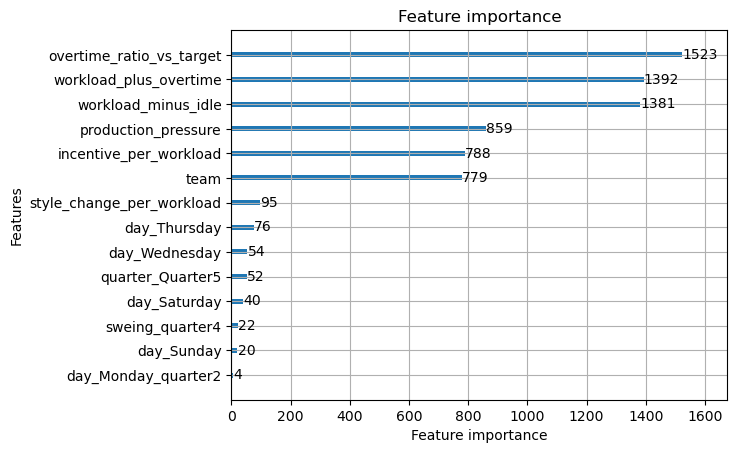

In [194]:
lgb.plot_importance(model, max_num_features=15)
plt.show()

In [195]:
data["work_pressure"] = data["production_pressure"] * data["overtime_ratio_vs_target"]
data["efficiency_signal"] = data["incentive_per_workload"] / (data["production_pressure"] + 1)
data["idle_pressure"] = data["workload_minus_idle"] / (data["production_pressure"] + 1)

In [196]:
drop_cols = ["day_Monday_quarter2","day_Sunday","sweing_quarter4","production_pressure","overtime_ratio_vs_target","incentive_per_workload","workload_minus_idle"]

In [197]:
data = data.drop(columns=drop_cols,axis=1)

In [198]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   team                       1160 non-null   int64   
 1   idle_time                  1160 non-null   float64 
 2   quarter_Quarter5           1160 non-null   int64   
 3   day_Saturday               1160 non-null   int64   
 4   day_Thursday               1160 non-null   int64   
 5   day_Wednesday              1160 non-null   int64   
 6   idle_per_workload          1160 non-null   float64 
 7   style_change_per_workload  1160 non-null   float64 
 8   day_Tuesday_quarter3       1160 non-null   int64   
 9   workload_plus_overtime     1160 non-null   float64 
 10  productivity_class         1160 non-null   category
 11  work_pressure              1160 non-null   float64 
 12  efficiency_signal          1160 non-null   float64 
 13  idle_pressure              1160 non-nu

In [199]:
data["effective_workload"] = data["workload_plus_overtime"] - data["idle_time"]
data["team_pressure"] = data["team"] * data["work_pressure"]
data["style_workload_pressure"] = data["style_change_per_workload"] * data["work_pressure"]
data["efficiency_idle_ratio"] = data["efficiency_signal"] / (data["idle_pressure"] + 1)
data["week_pressure"] = ( data["day_Saturday"] + data["day_Thursday"] + data["day_Wednesday"]) * data["work_pressure"]
data["quarter_pressure"] = data["quarter_Quarter5"] * data["work_pressure"]

In [200]:
drop_cols = ["workload_plus_overtime","idle_time","team","work_pressure","style_change_per_workload","efficiency_signal","idle_pressure","day_Saturday","day_Thursday","day_Wednesday","quarter_Quarter5"]

In [201]:
data = data.drop(columns=drop_cols,axis=1)

In [202]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 1196
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idle_per_workload        1160 non-null   float64 
 1   day_Tuesday_quarter3     1160 non-null   int64   
 2   productivity_class       1160 non-null   category
 3   effective_workload       1160 non-null   float64 
 4   team_pressure            1160 non-null   float64 
 5   style_workload_pressure  1160 non-null   float64 
 6   efficiency_idle_ratio    1160 non-null   float64 
 7   week_pressure            1160 non-null   float64 
 8   quarter_pressure         1160 non-null   float64 
dtypes: category(1), float64(7), int64(1)
memory usage: 82.8 KB


In [203]:
data.head()

,idle_per_workload,day_Tuesday_quarter3,productivity_class,effective_workload,team_pressure,style_workload_pressure,efficiency_idle_ratio,week_pressure,quarter_pressure
0,0.0,0,High,2049.300000,50825.688073,0.0,4.417176e-07,6353.211009,0.0
1,0.0,0,High,162.026667,42192.893401,0.0,0.000000e+00,42192.893401,0.0
2,0.0,0,High,555.006250,139982.471516,0.0,8.056872e-06,12725.679229,0.0
3,0.0,0,High,555.006250,152708.150745,0.0,8.056872e-06,12725.679229,0.0
4,0.0,0,High,1847.285714,11616.105902,0.0,2.683944e-07,1936.017650,0.0


In [204]:
data["style_workload_pressure"].unique()

array([0.00000000e+00, 1.96622209e-02, 1.96385042e-02, 2.95414190e-02,
       1.50852234e-02, 3.31515897e-02, 3.54745634e-02, 3.39536334e-02,
       4.03567452e-02, 4.17741529e-02, 2.75756384e-02, 2.07600498e-02,
       1.57571198e-02, 8.01101320e-04, 7.68163062e-02, 1.59425671e-02,
       3.45866194e-02, 2.18736386e-01, 4.53925599e-02, 3.03167745e-02,
       1.84567089e-02, 2.17265201e-02, 3.52093244e-02, 2.18736386e-01,
       4.96486397e-02, 3.35212450e-02, 1.60212449e-02, 1.90692260e-01,
       3.43818970e-02, 5.35858832e-02, 1.60314028e-01, 4.28684350e-03,
       3.62172089e-02, 2.52800709e-03, 5.32687207e-04, 1.43297988e-01,
       2.11174635e-01, 2.04266992e-01, 3.37153623e-02, 2.53703568e-03,
       3.15327133e-01, 5.59876017e-02, 2.49868121e-01, 3.48581545e-02,
       2.01337409e-01, 2.34605402e-03, 6.77596185e-03, 1.54517503e-01,
       3.48502934e-02, 1.56951485e-01, 5.48088491e-02, 3.32452564e-02,
       9.72499129e-03, 1.78923404e-01, 8.70080734e-02, 2.09469529e-01,
      

In [205]:
X = data.drop("productivity_class",axis=1)
y = data["productivity_class"]

In [206]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [207]:
model = LGBMClassifier(subsample=1.0,num_leaves=255,n_estimators=100,min_child_samples=30,max_depth=-1,learning_rate=0.05,colsample_bytree=0.6,
                      class_weight={"Low":1.5,"Medium":1.0,"High":1.2},random_state=42,verbose=-1)

In [208]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,"{'High': 1.2, 'Low': 1.5, 'Medium': 1.0}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [209]:
y_pred = model.predict(X_test)

In [210]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7068965517241379
Classification Report:                precision    recall  f1-score   support

        High       0.73      0.83      0.78       105
         Low       0.61      0.63      0.62        43
      Medium       0.72      0.60      0.65        84

    accuracy                           0.71       232
   macro avg       0.69      0.68      0.68       232
weighted avg       0.71      0.71      0.70       232

Confusion Matrix: 
  [[87  6 12]
 [ 9 27  7]
 [23 11 50]]


In [211]:
df = pd.read_csv("garments_worker_productivity.csv")

In [212]:
data["smv"] = df["smv"]
data["wip"] = df["wip"]
data["over_time"] = df["over_time"]
data["incentive"] = df["incentive"]
data["no_of_workers"] = df["no_of_workers"]
data["targeted_productivity"] = df["targeted_productivity"]

In [213]:
data["wip"].fillna(data["wip"].median(),inplace=True)

In [214]:
data["overtime_per_worker"] = data["over_time"] / data["no_of_workers"]

data["incentive_per_worker"] = data["incentive"] / data["no_of_workers"]

data["wip_per_worker"] = data["wip"] / data["no_of_workers"]

data["smv_per_worker"] = data["smv"] / data["no_of_workers"]

In [215]:
data.head()

,idle_per_workload,day_Tuesday_quarter3,productivity_class,effective_workload,team_pressure,style_workload_pressure,efficiency_idle_ratio,week_pressure,quarter_pressure,smv,wip,over_time,incentive,no_of_workers,targeted_productivity,overtime_per_worker,incentive_per_worker,wip_per_worker,smv_per_worker
0,0.0,0,High,2049.300000,50825.688073,0.0,4.417176e-07,6353.211009,0.0,26.16,1108.0,7080,98,59.0,0.80,120.000000,1.661017,18.779661,0.443390
1,0.0,0,High,162.026667,42192.893401,0.0,0.000000e+00,42192.893401,0.0,3.94,1028.5,960,0,8.0,0.75,120.000000,0.000000,128.562500,0.492500
2,0.0,0,High,555.006250,139982.471516,0.0,8.056872e-06,12725.679229,0.0,11.41,968.0,3660,50,30.5,0.80,120.000000,1.639344,31.737705,0.374098
3,0.0,0,High,555.006250,152708.150745,0.0,8.056872e-06,12725.679229,0.0,11.41,968.0,3660,50,30.5,0.80,120.000000,1.639344,31.737705,0.374098
4,0.0,0,High,1847.285714,11616.105902,0.0,2.683944e-07,1936.017650,0.0,25.90,1170.0,1920,50,56.0,0.80,34.285714,0.892857,20.892857,0.462500


In [216]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1160 entries, 0 to 1196
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   idle_per_workload        1160 non-null   float64 
 1   day_Tuesday_quarter3     1160 non-null   int64   
 2   productivity_class       1160 non-null   category
 3   effective_workload       1160 non-null   float64 
 4   team_pressure            1160 non-null   float64 
 5   style_workload_pressure  1160 non-null   float64 
 6   efficiency_idle_ratio    1160 non-null   float64 
 7   week_pressure            1160 non-null   float64 
 8   quarter_pressure         1160 non-null   float64 
 9   smv                      1160 non-null   float64 
 10  wip                      1160 non-null   float64 
 11  over_time                1160 non-null   int64   
 12  incentive                1160 non-null   int64   
 13  no_of_workers            1160 non-null   float64 
 14  targeted_prod

In [217]:
X = data.drop("productivity_class",axis=1)
y = data["productivity_class"]

In [218]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [219]:
model = LGBMClassifier(subsample=1.0,num_leaves=255,n_estimators=100,min_child_samples=30,max_depth=-1,learning_rate=0.05,colsample_bytree=0.6,
                      class_weight={"Low":1.5,"Medium":1.0,"High":1.2},random_state=42,verbose=-1)

In [220]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,"{'High': 1.2, 'Low': 1.5, 'Medium': 1.0}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [221]:
y_pred = model.predict(X_test)

In [222]:
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("Classification Report: ", classification_report(y_test,y_pred))
print("Confusion Matrix: \n ", confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7844827586206896
Classification Report:                precision    recall  f1-score   support

        High       0.87      0.86      0.87       105
         Low       0.62      0.72      0.67        43
      Medium       0.77      0.73      0.75        84

    accuracy                           0.78       232
   macro avg       0.76      0.77      0.76       232
weighted avg       0.79      0.78      0.79       232

Confusion Matrix: 
  [[90  6  9]
 [ 3 31  9]
 [10 13 61]]
